# Data Cleaning & Reporting Automation

## Project Overview

This project automates the process of cleaning messy sales data and generating business reports.

## Automated Data Cleaning

- Removed duplicate records
- Handled missing values
- Standardized text values
- Converted dates into a consistent format
- Converted numeric columns to appropriate data types
- Calculated revenue automatically

## Automated Reporting

- Total revenue
- Total quantity sold
- Total orders
- Average order value
- Top product
- Top region
- Monthly revenue analysis
- Product performance
- Regional performance

## Outputs

- Cleaned CSV dataset
- Automated Excel report
- Revenue charts
- Monthly trend visualization

## Technologies

Python | Pandas | NumPy | Matplotlib | Seaborn | Excel | Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Create a messy sales dataset

data = {
    "OrderID": [
        1001, 1002, 1003, 1004, 1005,
        1006, 1007, 1008, 1009, 1010,
        1003, 1012, 1013, 1014, 1015
    ],

    "Date": [
        "2026-01-05", "05/01/2026", "2026-01-12", None, "2026-01-18",
        "2026-02-03", "03-02-2026", "2026-02-15", "2026-02-22", "2026-03-04",
        "2026-01-12", "2026-03-11", "2026/03/17", "2026-03-25", "2026-04-02"
    ],

    "Region": [
        "North", "north", "South", "East", "WEST",
        "West", "south", "East", "east", "North",
        "South", "WEST", None, "North", "north"
    ],

    "Category": [
        "Electronics", "electronics", "Furniture", "Furniture", "Office Supplies",
        "office supplies", "Furniture", "ELECTRONICS", "Electronics", None,
        "Furniture", "Electronics", "Office Supplies", "office supplies", "Electronics"
    ],

    "Product": [
        "Laptop", "Laptop", "Office Chair", "Desk", "Notebook",
        "Printer Paper", "Desk", "Keyboard", "Headphones", "Monitor",
        "Office Chair", "Headphones", "Notebook", "Printer Paper", "Monitor"
    ],

    "Quantity": [
        2, 3, 5, 4, None,
        20, 6, 12, 15, 6,
        5, 15, 25, 30, "7"
    ],

    "UnitPrice": [
        750, 750, 120, 300, 8,
        12, 300, 35, 45, 220,
        120, 45, 8, 12, 220
    ],

    "Salesperson": [
        "Alice", "Alice", "Bob", "Bob", "David",
        "David", "Bob", "Carol", "Carol", "Alice",
        "Bob", "Carol", "David", "David", "Alice"
    ]
}

messy_df = pd.DataFrame(data)

messy_df

,OrderID,Date,Region,Category,Product,Quantity,UnitPrice,Salesperson
0,1001,2026-01-05,North,Electronics,Laptop,2,750,Alice
1,1002,05/01/2026,north,electronics,Laptop,3,750,Alice
2,1003,2026-01-12,South,Furniture,Office Chair,5,120,Bob
3,1004,None,East,Furniture,Desk,4,300,Bob
4,1005,2026-01-18,WEST,Office Supplies,Notebook,None,8,David
5,1006,2026-02-03,West,office supplies,Printer Paper,20,12,David
6,1007,03-02-2026,south,Furniture,Desk,6,300,Bob
7,1008,2026-02-15,East,ELECTRONICS,Keyboard,12,35,Carol
8,1009,2026-02-22,east,Electronics,Headphones,15,45,Carol
9,1010,2026-03-04,North,None,Monitor,6,220,Alice


In [3]:
messy_df.to_csv(
    "data/messy_sales_data.csv",
    index=False
)

print("Messy dataset saved successfully!")

Messy dataset saved successfully!


In [4]:
print("Rows:", messy_df.shape[0])
print("Columns:", messy_df.shape[1])

messy_df.info()

Rows: 15
Columns: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   OrderID      15 non-null     int64 
 1   Date         14 non-null     object
 2   Region       14 non-null     object
 3   Category     14 non-null     object
 4   Product      15 non-null     object
 5   Quantity     14 non-null     object
 6   UnitPrice    15 non-null     int64 
 7   Salesperson  15 non-null     object
dtypes: int64(2), object(6)
memory usage: 1.1+ KB


In [5]:
messy_df.isnull().sum()

OrderID        0
Date           1
Region         1
Category       1
Product        0
Quantity       1
UnitPrice      0
Salesperson    0
dtype: int64

In [6]:
messy_df.duplicated().sum()

np.int64(1)

In [7]:
# Make a copy so the original messy data remains unchanged
clean_df = messy_df.copy()

# Remove duplicate OrderIDs
clean_df = clean_df.drop_duplicates(subset="OrderID", keep="first")

print("Rows before cleaning:", len(messy_df))
print("Rows after removing duplicates:", len(clean_df))

Rows before cleaning: 15
Rows after removing duplicates: 14


In [8]:
# Clean text columns

text_columns = ["Region", "Category", "Product", "Salesperson"]

for col in text_columns:
    clean_df[col] = (
        clean_df[col]
        .astype("string")
        .str.strip()
        .str.title()
    )

print("Text columns cleaned successfully!")

Text columns cleaned successfully!


In [9]:
# Convert Date to datetime

clean_df["Date"] = pd.to_datetime(
    clean_df["Date"],
    errors="coerce",
    dayfirst=False
)

print("Date column cleaned successfully!")

Date column cleaned successfully!


In [10]:
# Convert Date to datetime

clean_df["Date"] = pd.to_datetime(
    clean_df["Date"],
    errors="coerce",
    dayfirst=False
)

print("Date column cleaned successfully!")

Date column cleaned successfully!


In [11]:
# Convert numeric columns

clean_df["Quantity"] = pd.to_numeric(
    clean_df["Quantity"],
    errors="coerce"
)

clean_df["UnitPrice"] = pd.to_numeric(
    clean_df["UnitPrice"],
    errors="coerce"
)

print("Numeric columns cleaned successfully!")

Numeric columns cleaned successfully!


In [12]:
# Handle missing values

clean_df["Quantity"] = clean_df["Quantity"].fillna(
    clean_df["Quantity"].median()
)

clean_df["UnitPrice"] = clean_df["UnitPrice"].fillna(
    clean_df["UnitPrice"].median()
)

clean_df["Region"] = clean_df["Region"].fillna("Unknown")
clean_df["Category"] = clean_df["Category"].fillna("Unknown")

# Date is essential for reporting, so remove rows with missing dates
clean_df = clean_df.dropna(subset=["Date"])

print("Missing values handled successfully!")

Missing values handled successfully!


In [13]:
# Calculate revenue

clean_df["Revenue"] = (
    clean_df["Quantity"] * clean_df["UnitPrice"]
)

clean_df.head()

,OrderID,Date,Region,Category,Product,Quantity,UnitPrice,Salesperson,Revenue
0,1001,2026-01-05,North,Electronics,Laptop,2.0,750,Alice,1500.0
2,1003,2026-01-12,South,Furniture,Office Chair,5.0,120,Bob,600.0
4,1005,2026-01-18,West,Office Supplies,Notebook,7.0,8,David,56.0
5,1006,2026-02-03,West,Office Supplies,Printer Paper,20.0,12,David,240.0
7,1008,2026-02-15,East,Electronics,Keyboard,12.0,35,Carol,420.0


In [14]:
print("===== CLEANED DATA CHECK =====")

print("Rows:", clean_df.shape[0])
print("Columns:", clean_df.shape[1])

print("\nMissing values:")
print(clean_df.isnull().sum())

print("\nDuplicate OrderIDs:")
print(clean_df["OrderID"].duplicated().sum())

print("\nData types:")
print(clean_df.dtypes)

===== CLEANED DATA CHECK =====
Rows: 10
Columns: 9

Missing values:
OrderID        0
Date           0
Region         0
Category       0
Product        0
Quantity       0
UnitPrice      0
Salesperson    0
Revenue        0
dtype: int64

Duplicate OrderIDs:
0

Data types:
OrderID                 int64
Date           datetime64[ns]
Region         string[python]
Category       string[python]
Product        string[python]
Quantity              float64
UnitPrice               int64
Salesperson    string[python]
Revenue               float64
dtype: object


In [15]:
clean_df.to_csv(
    "reports/cleaned_sales_data.csv",
    index=False
)

print("Cleaned sales data exported successfully!")

Cleaned sales data exported successfully!


In [16]:
# Automated KPI calculations

total_revenue = clean_df["Revenue"].sum()
total_quantity = clean_df["Quantity"].sum()
total_orders = clean_df["OrderID"].nunique()
average_order_value = total_revenue / total_orders

top_product = (
    clean_df.groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

top_region = (
    clean_df.groupby("Region")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

print("=" * 55)
print("       AUTOMATED SALES PERFORMANCE REPORT")
print("=" * 55)
print(f"Total Revenue        : ${total_revenue:,.2f}")
print(f"Total Quantity Sold  : {total_quantity:,.0f}")
print(f"Total Orders         : {total_orders:,}")
print(f"Average Order Value  : ${average_order_value:,.2f}")
print(f"Top Product          : {top_product}")
print(f"Top Region           : {top_region}")
print("=" * 55)

       AUTOMATED SALES PERFORMANCE REPORT
Total Revenue        : $7,386.00
Total Quantity Sold  : 119
Total Orders         : 10
Average Order Value  : $738.60
Top Product          : Monitor
Top Region           : North


In [17]:
# Monthly revenue summary

monthly_report = (
    clean_df.groupby(clean_df["Date"].dt.to_period("M"))["Revenue"]
    .sum()
    .reset_index()
)

monthly_report["Date"] = monthly_report["Date"].astype(str)

monthly_report

,Date,Revenue
0,2026-01,2156.0
1,2026-02,1335.0
2,2026-03,2355.0
3,2026-04,1540.0


In [18]:
# Product performance

product_report = (
    clean_df.groupby("Product")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Orders=("OrderID", "nunique")
    )
    .sort_values("Total_Revenue", ascending=False)
    .reset_index()
)

product_report

,Product,Total_Revenue,Total_Quantity,Orders
0,Monitor,2860.0,13.0,2
1,Laptop,1500.0,2.0,1
2,Headphones,1350.0,30.0,2
3,Office Chair,600.0,5.0,1
4,Printer Paper,600.0,50.0,2
5,Keyboard,420.0,12.0,1
6,Notebook,56.0,7.0,1


In [19]:
# Regional performance

region_report = (
    clean_df.groupby("Region")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Orders=("OrderID", "nunique")
    )
    .sort_values("Total_Revenue", ascending=False)
    .reset_index()
)

region_report

,Region,Total_Revenue,Total_Quantity,Orders
0,North,4720.0,45.0,4
1,East,1095.0,27.0,2
2,West,971.0,42.0,3
3,South,600.0,5.0,1


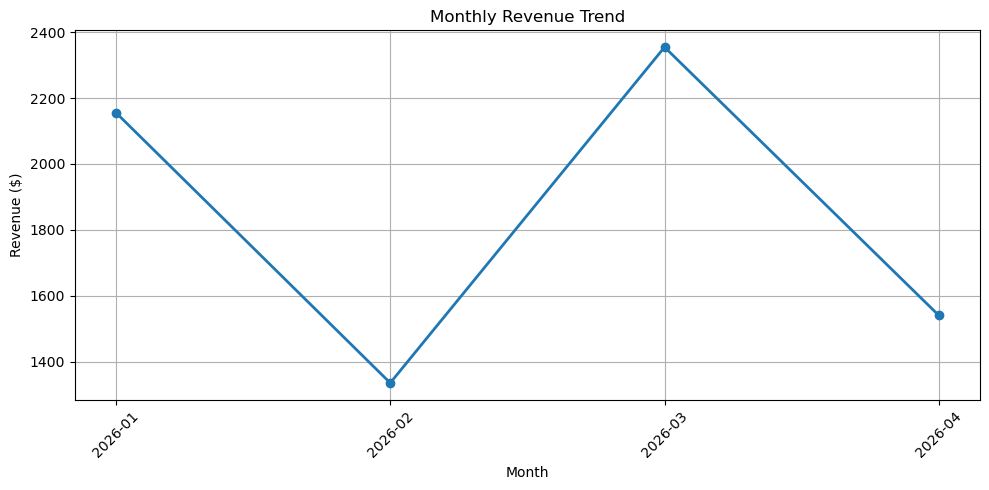

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_report["Date"],
    monthly_report["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.savefig("reports/monthly_revenue_trend.png", dpi=300)
plt.show()

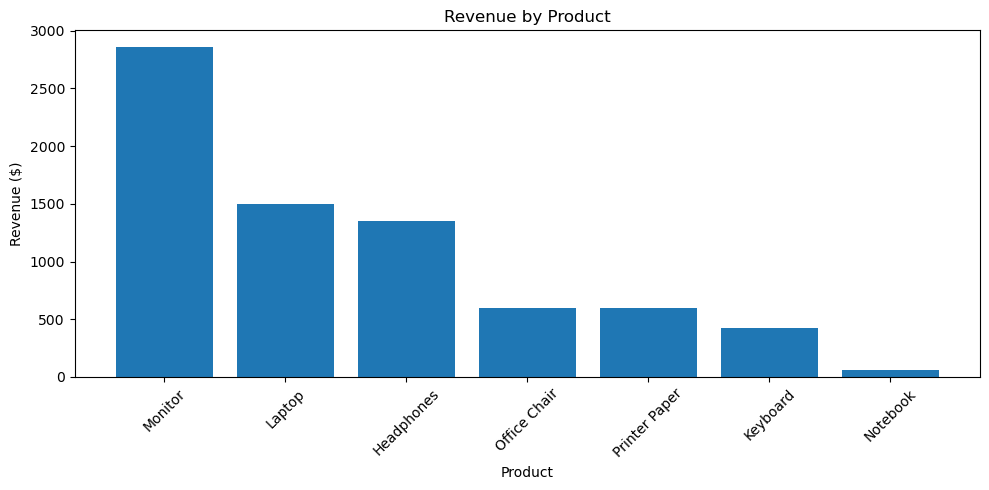

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    product_report["Product"],
    product_report["Total_Revenue"]
)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("reports/revenue_by_product.png", dpi=300)
plt.show()

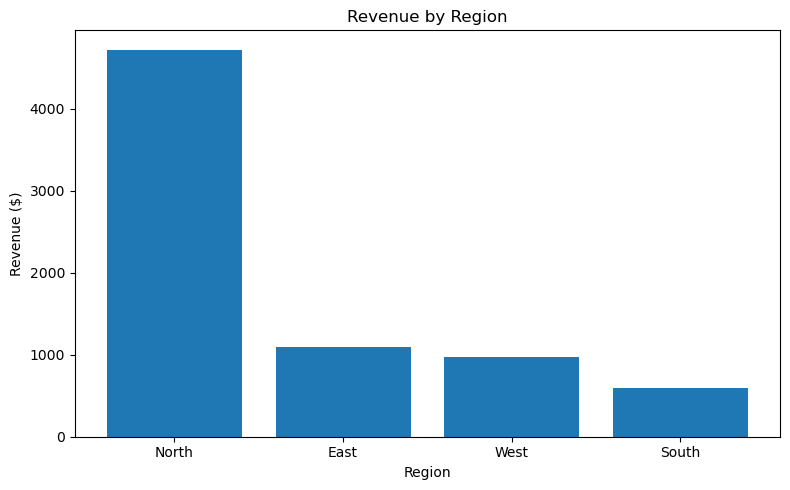

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_report["Region"],
    region_report["Total_Revenue"]
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue ($)")

plt.tight_layout()
plt.savefig("reports/revenue_by_region.png", dpi=300)
plt.show()

In [25]:
# Generate automated Excel report

report_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Quantity Sold",
        "Total Orders",
        "Average Order Value",
        "Top Product",
        "Top Region"
    ],
    "Value": [
        total_revenue,
        total_quantity,
        total_orders,
        average_order_value,
        top_product,
        top_region
    ]
})

with pd.ExcelWriter(
    "reports/sales_report.xlsx",
    engine="openpyxl"
) as writer:

    report_summary.to_excel(
        writer,
        sheet_name="KPI Summary",
        index=False
    )

    monthly_report.to_excel(
        writer,
        sheet_name="Monthly Revenue",
        index=False
    )

    product_report.to_excel(
        writer,
        sheet_name="Product Performance",
        index=False
    )

    region_report.to_excel(
        writer,
        sheet_name="Regional Performance",
        index=False
    )

print("Automated Excel report created successfully!")

Automated Excel report created successfully!
